In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
from itertools import combinations
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
from scipy.stats import median_abs_deviation
import scanpy.external as sce

import rmm
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator

sc.settings.verbosity = 3

In [3]:
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

# Load in raw anndata

In [64]:
start = time.perf_counter()

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/raw_merged_gene_data.h5ad"

adata_raw = sc.read_h5ad(path)

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")

print(f"Initial shape: {adata_raw.shape}\n")
print(f"N cells in HYB dataset: {adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs}")
print(f"N cells in scFib dataset: {adata_raw[adata_raw.obs['dataset'] == 'Control'].n_obs}\n")


### --- Handle HYB cells with NaN feature barcode predictions ---
init_cells_hybrid = adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs

# remove HYB cells with NaN feature barcode predictions
hybrid_to_remove = (adata_raw.obs['dataset'] == 'Hybrid') & (adata_raw.obs['assigned_condition'].isna())
cells_to_keep = ~(hybrid_to_remove)
adata_raw = adata_raw[cells_to_keep].copy()

final_cells_hybrid = adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs
removed_hybrid_cells = init_cells_hybrid - final_cells_hybrid

print(f"Removed {removed_hybrid_cells} 'Hybrid' cells with unassigned feature barcodes")

### --- Add new column for grouping HYB cells vs Controls ---
adata_raw.obs['pooled_condition'] = adata_raw.obs['assigned_condition'].replace({
    "G1": "Control",
    "S": "Control",
    "G2M": "Control",
    "PRRX1": "siPRRX1",
    "PRRX1_MYOD": "siPRRX1/mmMYOD1",
    "MYOD": "mmMYOD1"
})

# fill remaining NaN feature barcode predictions (only control cells) with 'Control'
adata_raw.obs['pooled_condition'] = adata_raw.obs['pooled_condition'].fillna('Control')
print(adata_raw.obs['pooled_condition'].value_counts())

print(f"Final shape: {adata_raw.shape}")
adata_raw

Memory usage: current 25.14 GB, difference +13.46 GB
Total time: 1.45 seconds
Initial shape: (19858, 28702)

N cells in HYB dataset: 10895
N cells in scFib dataset: 8963

Removed 1 'Hybrid' cells with unassigned feature barcodes
pooled_condition
Control            8963
siPRRX1/mmMYOD1    4174
siPRRX1            3955
mmMYOD1            2765
Name: count, dtype: int64
Final shape: (19857, 28702)


/tmp/ipykernel_2731514/805289867.py:29: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_raw.obs['pooled_condition'] = adata_raw.obs['assigned_condition'].replace({


AnnData object with n_obs × n_vars = 19857 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'

# Create AnnData subsets

### mmMYOD1 only

In [65]:
print("Subsetting raw adata for mmMYOD1 cells with positive MYOD1 expression and Controls...\n")

init_cells = adata_raw.n_obs

# Extract MYOD1 expression as a dense 1D array
myod1_expr = adata_raw[:, 'MYOD1'].X.toarray().flatten()

# Create a mask for mmMYOD1 cells with non-zero MYOD1 expression and controls
cells_to_keep = ((adata_raw.obs['pooled_condition'] == 'mmMYOD1') & (myod1_expr > 0)) | (adata_raw.obs['dataset'] == 'Control')

mdata = adata_raw[cells_to_keep].copy()

final_cells = mdata.n_obs
print(f"Removed {init_cells - final_cells} cells. \nFinal cells in adata: {final_cells}")

mdata

Subsetting raw adata for mmMYOD1 cells with positive MYOD1 expression and Controls...

Removed 8387 cells. 
Final cells in adata: 11470


AnnData object with n_obs × n_vars = 11470 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'

# QC and filtering

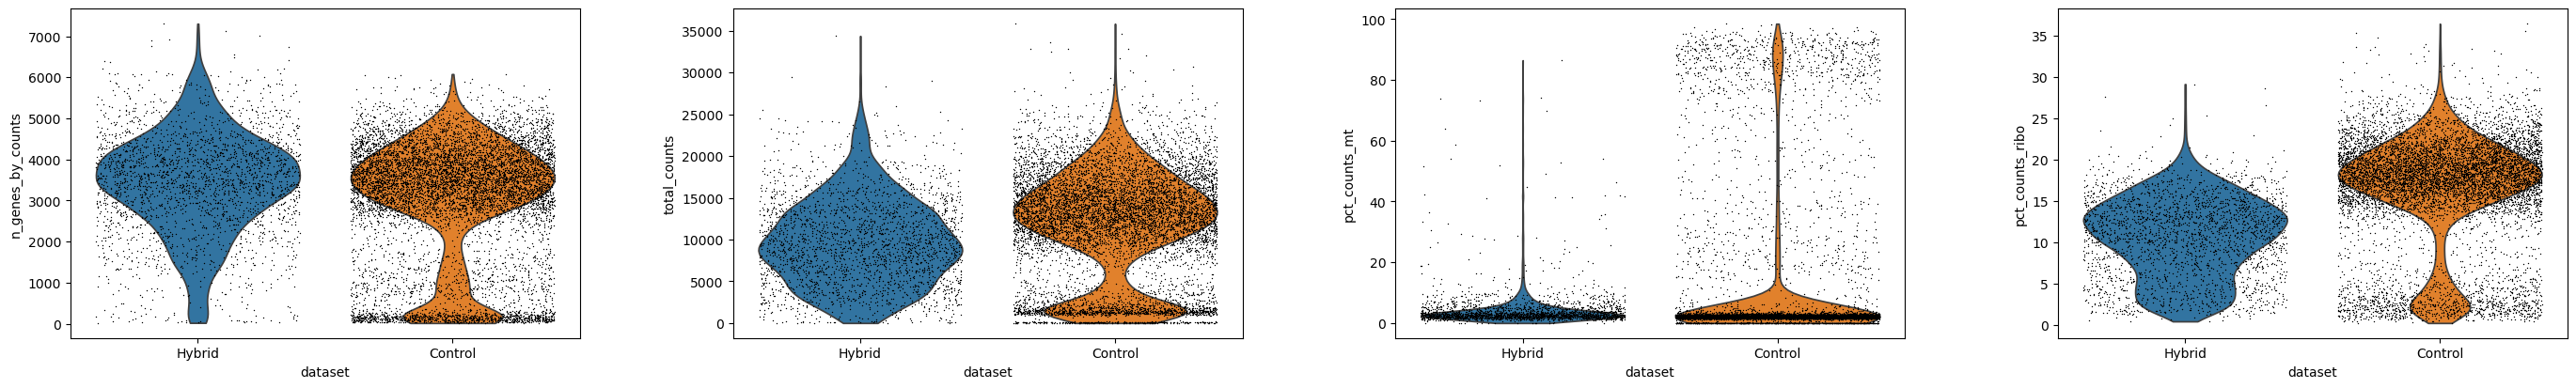

Number of outlier cells per dataset based on counts:
dataset
Hybrid      131
Control    1676
Name: outlier, dtype: int64

Number of outlier cells per dataset based on pct mito:
Total number of cells: 11470
N cells in Hybird: 2507
N cells in Control: 8963

Filtering...

Removed 2303 total cells.
Removed 300 from Hybrid dataset.
Removed 2003 from Control dataset.

Total cells after filtering of low quality cells: 9167
N cells in Hybird: 2207
N cells in Control: 6960


In [66]:
adata = mdata.copy()

# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

plt.rcdefaults()
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
    groupby='dataset',
)

# Identify outlier cells with MADs per dataset
def is_outlier_by_group(adata, metric: str, nmads: int, group_col: str = 'dataset'):
    outlier_series = pd.Series(False, index=adata.obs.index)
    unique_groups = adata.obs[group_col].unique()

    for group in unique_groups:
        group_mask = (adata.obs[group_col] == group)
        M_group = adata.obs.loc[group_mask, metric]

        if len(M_group) < 2 or M_group.isnull().all():
            continue

        median_val_group = np.median(M_group)
        mad_val_group = median_abs_deviation(M_group)

        if mad_val_group == 0:
            continue

        outliers_in_group = (M_group < median_val_group - nmads * mad_val_group) | \
                            (median_val_group + nmads * mad_val_group < M_group)

        outlier_series.loc[group_mask] = outliers_in_group

    return outlier_series


adata.obs["outlier"] = (
    is_outlier_by_group(adata, "log1p_total_counts", 5, 'dataset')
    | is_outlier_by_group(adata, "log1p_n_genes_by_counts", 5, 'dataset')
)

print("Number of outlier cells per dataset based on counts:")
print(adata.obs.groupby('dataset', observed=True)['outlier'].sum())


adata.obs["mt_outlier"] = is_outlier_by_group(adata, "pct_counts_mt", 5, 'dataset') | (
    adata.obs["pct_counts_mt"] > 20
)

print("\nNumber of outlier cells per dataset based on pct mito:")
adata.obs.groupby('dataset', observed=True)['mt_outlier'].sum()

init_cells = adata.n_obs
init_cells_hyb = adata[adata.obs['dataset'] == 'Hybrid'].n_obs
init_cells_fib = adata[adata.obs['dataset'] == 'Control'].n_obs

print(f"Total number of cells: {init_cells}")
print(f"N cells in Hybird: {init_cells_hyb}")
print(f"N cells in Control: {init_cells_fib}")

print(f"\nFiltering...")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

final_cells = adata.n_obs
final_cells_hyb = adata[adata.obs['dataset'] == 'Hybrid'].n_obs
final_cells_fib = adata[adata.obs['dataset'] == 'Control'].n_obs

print(f"\nRemoved {init_cells - final_cells} total cells.")
print(f"Removed {init_cells_hyb - final_cells_hyb} from Hybrid dataset.")
print(f"Removed {init_cells_fib - final_cells_fib} from Control dataset.")

print(f"\nTotal cells after filtering of low quality cells: {final_cells}")
print(f"N cells in Hybird: {final_cells_hyb}")
print(f"N cells in Control: {final_cells_fib}")

In [67]:
# keep full dimension safe
adata.raw = adata  

# save raw counts
adata.layers['raw_counts'] = adata.X.copy()

sc.pp.filter_genes(adata, min_counts=10)

sc.pp.normalize_total(
    adata,
    target_sum=1e4,
)

# save normalized counts
adata.layers['norm_counts'] = adata.X.copy()

# log transform normalized counts
sc.pp.log1p(adata)

# save log normalized counts
adata.layers['log_norm'] = adata.X.copy()

adata

filtered out 5665 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 9167 × 23037
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'dataset_colors', 'log1p'
    layers: 'raw_counts', 'norm_counts', 'log_norm'

# PCA and clustering

filter_pass
True     22600
False      437
extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Number of HVG: 2353


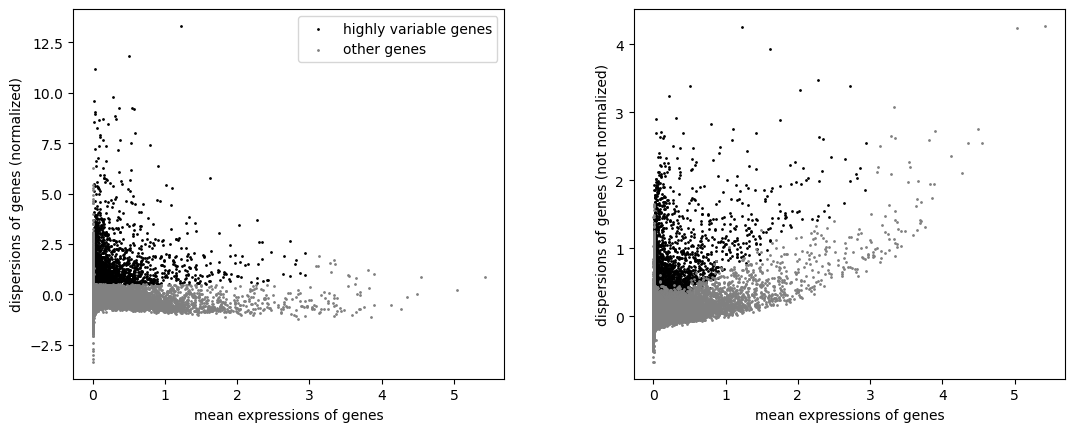

computing PCA
    with n_comps=50
    finished (0:00:14)


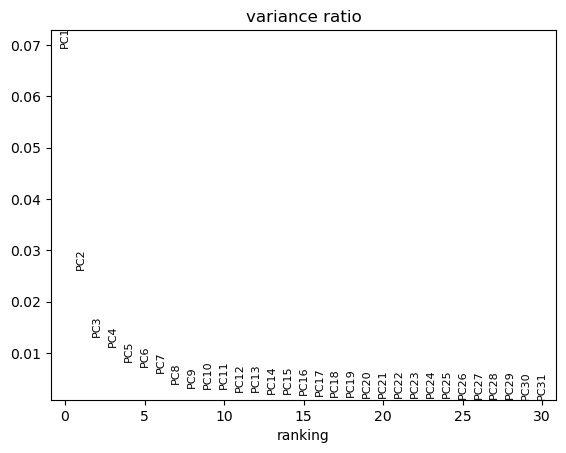

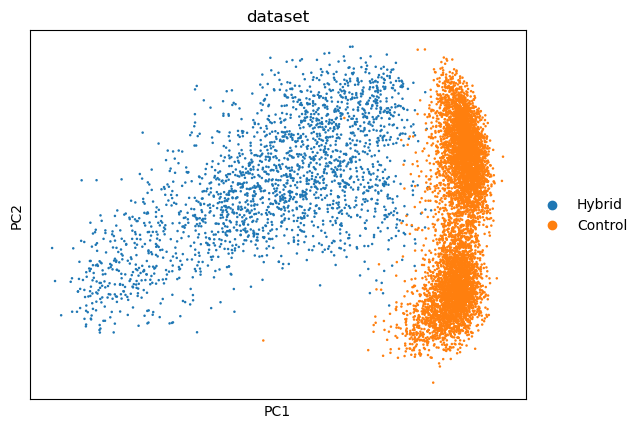

AnnData object with n_obs × n_vars = 9167 × 23037
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection

In [68]:
adata.var['filter_pass'] = True # set the gene filter

# disallow GO cell cycle genes
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

print(adata.var['filter_pass'].value_counts().to_string())


### HVGs
adata.X = adata.layers['log_norm']

sc.pp.highly_variable_genes(
    adata,
    batch_key='dataset',
)

print(f"Number of HVG: {adata.var['highly_variable'].sum()}")

plt.rcdefaults()
sc.pl.highly_variable_genes(adata)

### PCA with 'filter_pass' genes
sc.pp.pca(
    adata,
    mask_var='filter_pass',
)

sc.pl.pca_variance_ratio(adata)
sc.pl.pca(adata, color='dataset')

adata

2025-07-03 11:31:07,529 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-07-03 11:31:09,730 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-03 11:31:09,765 - harmonypy - INFO - Iteration 1 of 10
2025-07-03 11:31:11,554 - harmonypy - INFO - Iteration 2 of 10
2025-07-03 11:31:13,332 - harmonypy - INFO - Converged after 2 iterations


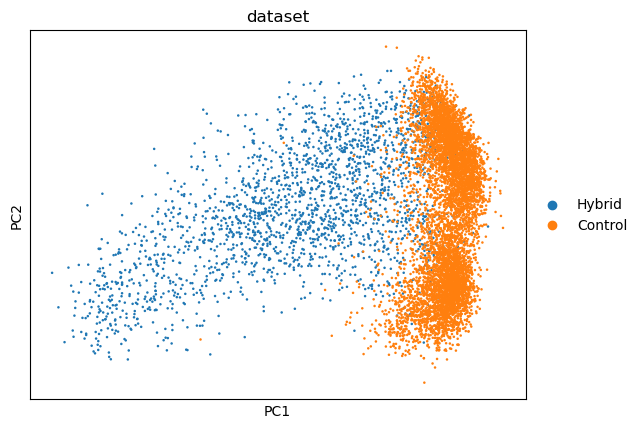

In [69]:
### Harmony integration
sce.pp.harmony_integrate(adata, 'dataset')

# Save original PCA space
adata.obsm["X_pca_original"] = adata.obsm["X_pca"].copy()

# Set Harmony-corrected PCA as the default for plotting
adata.obsm["X_pca"] = adata.obsm["X_pca_harmony"].copy()

sc.pl.pca(adata, color='dataset')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering
    finished: found 3 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering
    finished: found 2 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


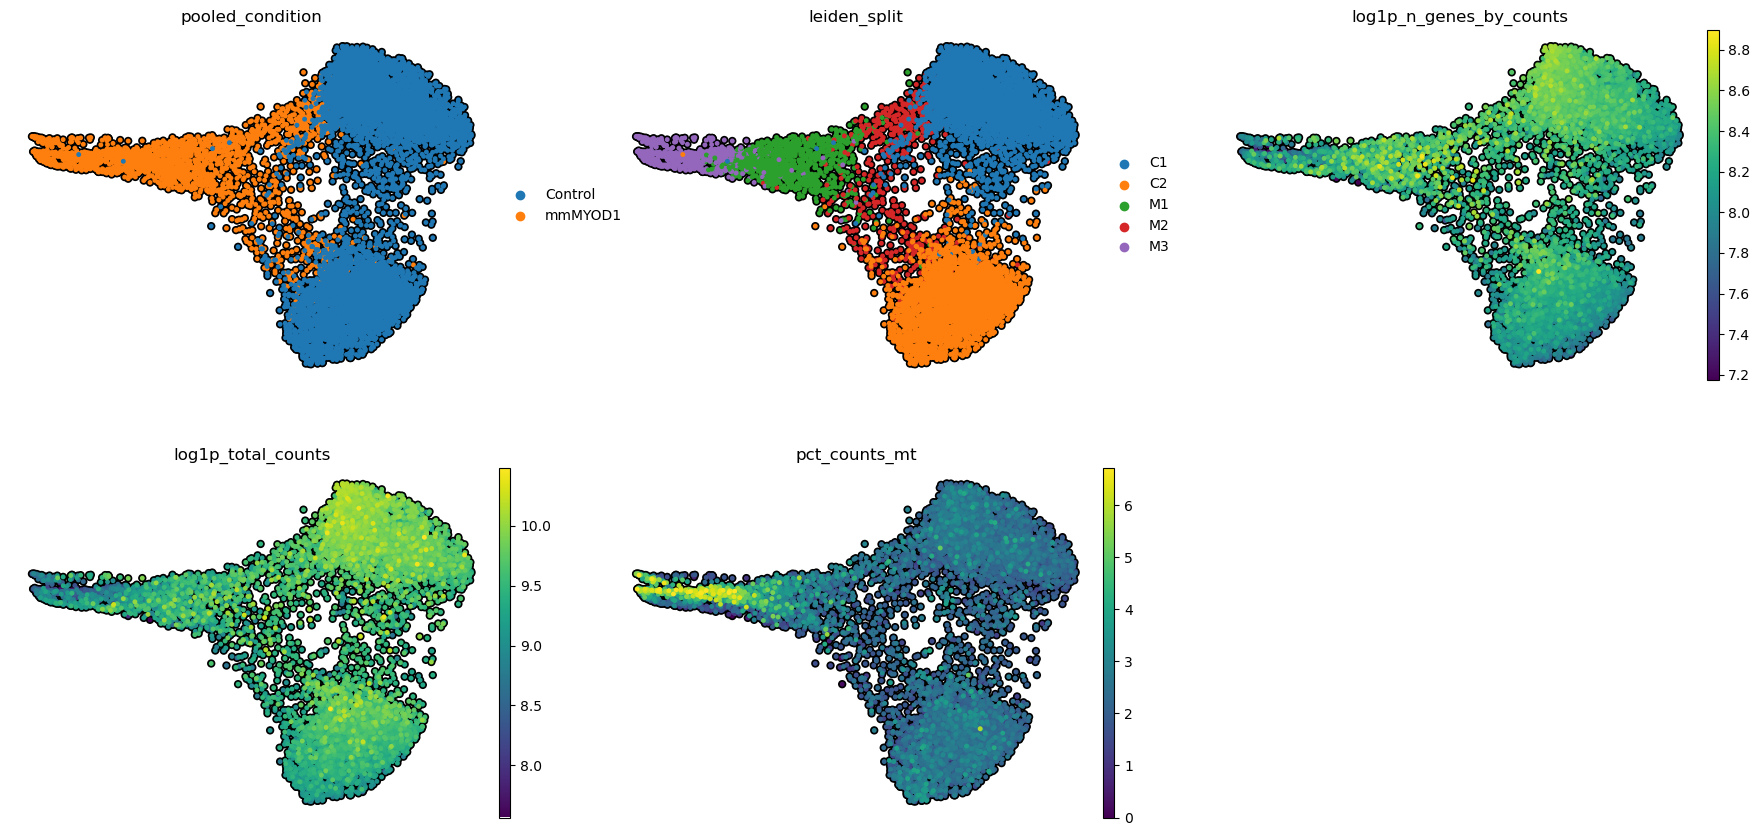

In [70]:
rsc.get.anndata_to_GPU(adata)

rsc.pp.neighbors(
    adata,
    use_rep='X_pca_harmony',
    n_neighbors=10,
)

rsc.tl.draw_graph(
    adata,
)

rsc.get.anndata_to_CPU(adata)


# Cluster mmMYOD1 cells separately from controls
subset_hyb = adata[adata.obs['pooled_condition'].isin(['mmMYOD1'])].copy()
sc.pp.neighbors(subset_hyb, n_neighbors=10, use_rep='X_pca_harmony')
sc.tl.leiden(subset_hyb, resolution=0.2, flavor='igraph')


# Cluster Control cells separately from mmMYOD1
subset_ctrl = adata[adata.obs['pooled_condition'] == 'Control'].copy()
sc.pp.neighbors(subset_ctrl, n_neighbors=10, use_rep='X_pca_harmony')
sc.tl.leiden(subset_ctrl, resolution=0.15, flavor='igraph')


# Add back to adata as one group
adata.obs['leiden_split'] = None
adata.obs.loc[subset_hyb.obs_names, 'leiden_split'] = ('M' + (subset_hyb.obs['leiden'].astype(int) + 1).astype(str))
adata.obs.loc[subset_ctrl.obs_names, 'leiden_split'] = ('C' + (subset_ctrl.obs['leiden'].astype(int) + 1).astype(str))


plt.rcdefaults()
sc.pl.draw_graph(
    adata,
    color=['pooled_condition', 'leiden_split', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt'],
    ncols=3,
    size=50,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

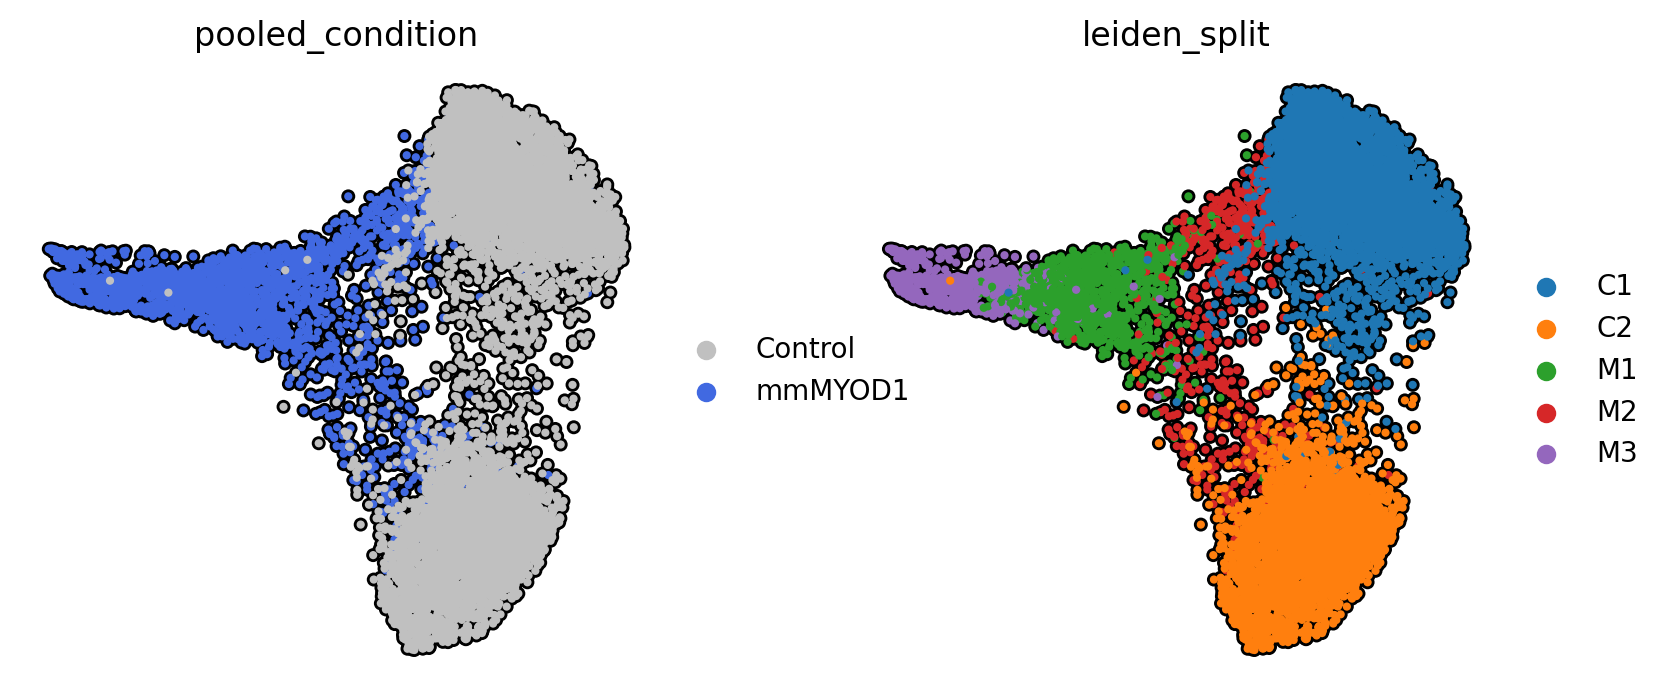

In [71]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

adata.uns['pooled_condition_colors'] = ["silver", "royalblue"]

sc.pl.draw_graph(
    adata,
    color=['pooled_condition', 'leiden_split'],
    ncols=2,
    size=35,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

In [72]:
adata

AnnData object with n_obs × n_vars = 9167 × 23037
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_varia

# Score cell cycle genes

S phase genes: 43
G2M phase genes: 54
calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    386 total control genes are used. (0:00:00)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    255 total control genes are used. (0:00:00)
-->     'phase', cell cycle phase (adata.obs)


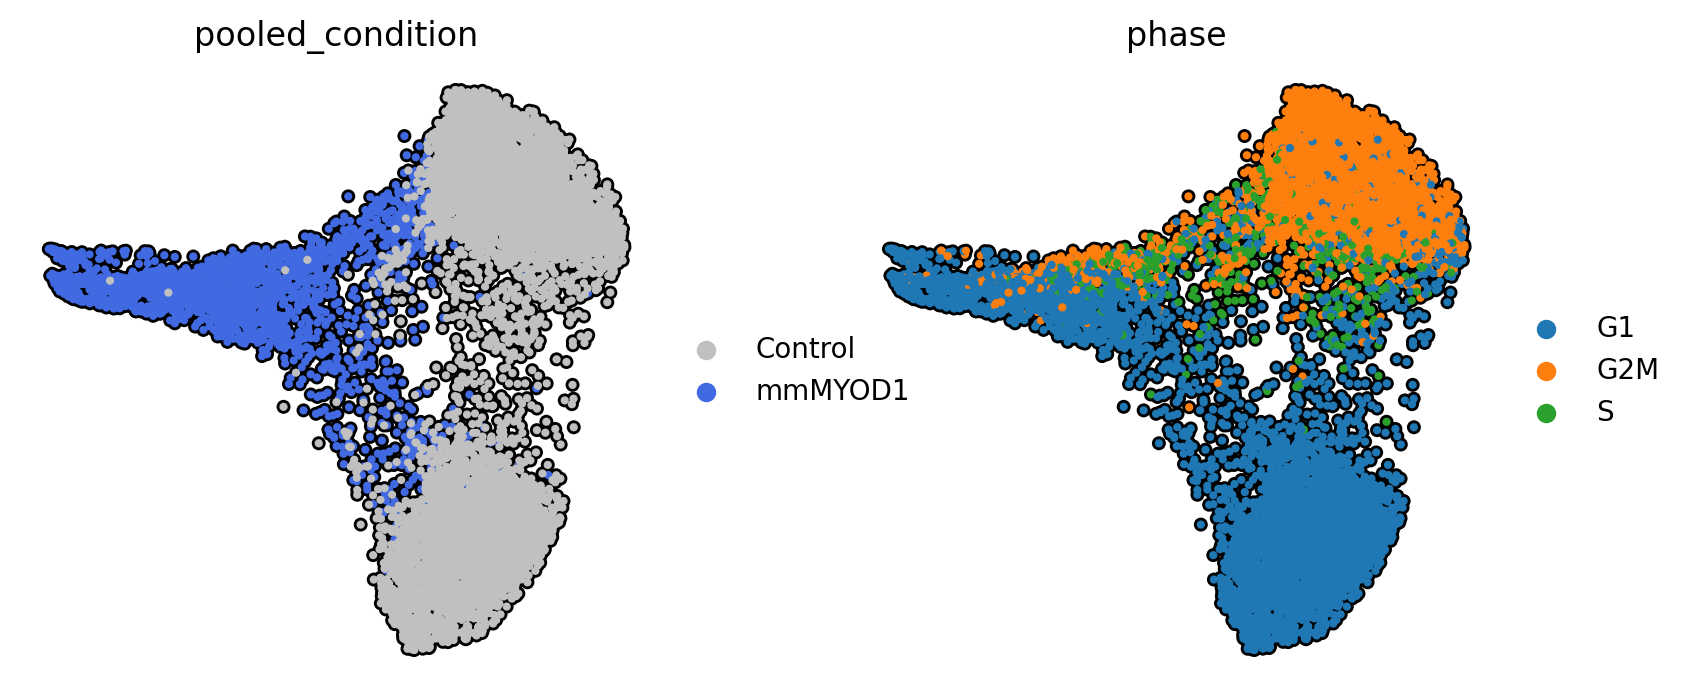

AnnData object with n_obs × n_vars = 9167 × 23037
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden_split', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_

In [73]:
path = "../../resources/regev_lab_cell_cycle_genes.txt"

cell_cycle_genes = [x.strip() for x in open(path)]

s_genes = cell_cycle_genes[:43]
print(f"S phase genes: {len(s_genes)}")

g2m_genes = cell_cycle_genes[43:]
print(f"G2M phase genes: {len(g2m_genes)}")

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

sc.pl.draw_graph(
    adata,
    color=['pooled_condition', 'phase'],
    ncols=2,
    size=35,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

adata

# DGE

In [77]:
### Each mmMYOD1 cluster vs controls
adata.obs['cluster_vs_control'] = np.where(adata.obs['leiden_split'].str.startswith('C'), 'Control', adata.obs['leiden_split'])

sc.tl.rank_genes_groups(
    adata, 
    groupby="cluster_vs_control",
    reference='Control',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='deg_cluster_vs_control',
)


### Each cluster vs eachother
sc.tl.rank_genes_groups(
    adata, 
    groupby="leiden_split",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='deg_all_clusters',
)


### All mmMYOD1 vs all controls
sc.tl.rank_genes_groups(
    adata, 
    groupby="pooled_condition",
    reference='Control',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='deg_myod_vs_control',
)

adata

ranking genes
    finished: added to `.uns['deg_cluster_vs_control']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:45)
ranking genes
    finished: added to `.uns['deg_all_clusters']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:18)
ranking genes
    finished: added to `.uns['deg_myod_vs_control']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray t

AnnData object with n_obs × n_vars = 9167 × 23037
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden_split', 'S_score', 'G2M_score', 'phase', 'cluster_vs_control'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'means', 'dispersions', 'dispe

In [78]:
adata.write_h5ad("/scratch/indikar_root/indikar1/shared_data/HYB/anndata/condition_subsets/mmMYOD1_controls_processed.h5ad")
adata

AnnData object with n_obs × n_vars = 9167 × 23037
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden_split', 'S_score', 'G2M_score', 'phase', 'cluster_vs_control'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'means', 'dispersions', 'dispe